In [27]:
#Imports and directory
import os
import pickle
import random
import math
import numpy as np
import pandas as pd
import matplotlib
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
#os.chdir("/home/ec2-user/CS-230-Deep-Learning-Project")
os.chdir(r"C:\VScode\Projet Stanford CS230\CS-230-Deep-Learning-Project")
#os.chdir(r"C:\Users\gotta\OneDrive\Documents\Bureau\X\4A\US\Stanford\Classes\CS 230\Project\CS-230-Deep-Learning-Project")

In [28]:
# Basic functions including device and seeding
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print("USING DEVICE:", device)

def save_object_to_file(obj, filepath):
    with open(filepath, "wb") as f:
        pickle.dump(obj, f)

def read_object_from_file(filepath):
    with open(filepath, "rb") as f:
        return pickle.load(f)

def seed_everything(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


USING DEVICE: cpu


In [36]:
# --- Data preparation ---
DATA_CSV_FR = os.path.join("data", "FR_LMP_Forecasts", "FR_lmp_processed.csv")
DATA_CSV_LOAD = os.path.join("data", "FR_DAM_Load_Forecasts", "FR_load_processed.csv")
DATA_CSV_REN = os.path.join("data", "FR_REN_DAM_Forecasts", "FR_ren_processed.csv")
def split_data(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])
    train = df[(df['date'] >= '2019-10-01') & (df['date'] <= '2023-09-30')].reset_index(drop=True)
    dev   = df[(df['date'] >= '2023-10-01') & (df['date'] <= '2024-09-30')].reset_index(drop=True)
    test  = df[(df['date'] >= '2024-10-01') & (df['date'] <= '2025-09-30')].reset_index(drop=True)
    return train, dev, test

def create_sliding_window(data_df,string, window_days=7, forecast_horizon=1):
    """
    Create sliding windows for day-ahead electricity price forecasting.
    Each input corresponds to `window_days` past days (window_days * 24 hours),
    and each output corresponds to the next day's 24 hourly prices.

    Parameters
    ----------
    data_df : pd.DataFrame
        Must contain a 'EUR/MWh' column with hourly prices.
    window_days : int
        Number of past days (each 24 hours) used as input.
    forecast_horizon : int
        Typically 24 (hours in the day to forecast).
    string :  the name of the column of interest
    Returns
    -------
    X : np.ndarray of shape (n_samples, window_days*24)
    y : np.ndarray of shape (n_samples, forecast_horizon)
    """
    series = data_df[string].values
    hours_per_day = 24
    window_size = window_days * hours_per_day

    eps=1e-9

    X, y, y_day_before, y_week_before, y_pourcentage = [], [], [], [], []

    for i in range(0, len(series) - window_size - forecast_horizon + 1):
        # Input window: past `window_size` hours
        X_window = series[i : i + window_size]
        # Target: next `forecast_horizon` hours
        y_target = series[i + window_size : i + window_size + forecast_horizon]

        # --- Naive baselines ---
        # previous day
        if i - hours_per_day >= 0:
            y_prev_day = series[i + window_size - hours_per_day : i + window_size - hours_per_day + forecast_horizon]
        else:
            y_prev_day = np.full(forecast_horizon, np.nan)

        # previous week
        if i - 7 * hours_per_day >= 0:
            y_prev_week = series[i + window_size - 7 * hours_per_day : i + window_size - 7 * hours_per_day + forecast_horizon]
        else:
            y_prev_week = np.full(forecast_horizon, np.nan)

        X.append(X_window)
        y.append(y_target)
        y_day_before.append(y_prev_day)
        y_week_before.append(y_prev_week)
        y_pourcentage.append((y_target-X_window[-1])/(X_window[-1]+eps))

    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32), np.asarray(y_day_before, dtype=np.float32), np.asarray(y_week_before, dtype=np.float32), np.asarray(y_pourcentage, dtype=np.float32)

In [37]:
df_FR = pd.read_csv(DATA_CSV_FR)
load_FR = pd.read_csv(DATA_CSV_LOAD)
ren_FR = pd.read_csv(DATA_CSV_REN)
all_data=pd.merge(df_FR, load_FR, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'],how='inner')
all_data=pd.merge(all_data, ren_FR, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'],how='inner')
all_data


,Time,Year,Month,Day,Hour,Timezone,EUR/MWh,MW,Wind Onshore,Solar
0,2019-10-01 00:00:00+02:00,2019,10,1,0,+02:00,33.09,44450.0,4975.31,0.00
1,2019-10-01 01:00:00+02:00,2019,10,1,1,+02:00,27.72,41300.0,5338.58,0.00
2,2019-10-01 02:00:00+02:00,2019,10,1,2,+02:00,23.12,40050.0,5702.33,0.00
3,2019-10-01 03:00:00+02:00,2019,10,1,3,+02:00,16.46,37750.0,5667.94,0.00
4,2019-10-01 04:00:00+02:00,2019,10,1,4,+02:00,15.66,36600.0,5633.30,0.00
...,...,...,...,...,...,...,...,...,...,...
52182,2025-09-30 19:00:00+02:00,2025,9,30,19,+02:00,117.00,49000.0,2435.69,2158.72
52183,2025-09-30 20:00:00+02:00,2025,9,30,20,+02:00,106.18,50400.0,2929.19,315.89
52184,2025-09-30 21:00:00+02:00,2025,9,30,21,+02:00,83.23,46700.0,3480.47,0.00
52185,2025-09-30 22:00:00+02:00,2025,9,30,22,+02:00,73.00,44100.0,3879.11,0.00


In [38]:

#Normalization and splitting
train_df_FR, dev_df_FR, test_df_FR = split_data(all_data)

mean_FR = train_df_FR['EUR/MWh'].mean()
std_FR = train_df_FR['EUR/MWh'].std()
train_df_FR['EUR/MWh'] = (train_df_FR['EUR/MWh'] - mean_FR) / std_FR
dev_df_FR['EUR/MWh'] = (dev_df_FR['EUR/MWh'] - mean_FR) / std_FR
test_df_FR['EUR/MWh'] = (test_df_FR['EUR/MWh'] - mean_FR) / std_FR
mean_load_FR = train_df_FR['MW'].mean()
std_load_FR = train_df_FR['MW'].std()
train_df_FR['MW'] = (train_df_FR['MW'] - mean_load_FR) / std_load_FR
dev_df_FR['MW'] = (dev_df_FR['MW'] - mean_load_FR) / std_load_FR
test_df_FR['MW'] = (test_df_FR['MW'] - mean_load_FR) / std_load_FR
mean_solar_FR = train_df_FR['Solar'].mean()
std_solar_FR = train_df_FR['Solar'].std()
train_df_FR['Solar'] = (train_df_FR['Solar'] - mean_solar_FR) / std_solar_FR
dev_df_FR['Solar'] = (dev_df_FR['Solar'] - mean_solar_FR) / std_solar_FR
test_df_FR['Solar'] = (test_df_FR['Solar'] - mean_solar_FR) / std_solar_FR
mean_wind_FR = train_df_FR['Wind Onshore'].mean()
std_wind_FR = train_df_FR['Wind Onshore'].std()
train_df_FR['Wind Onshore'] = (train_df_FR['Wind Onshore'] - mean_wind_FR) / std_wind_FR
dev_df_FR['Wind Onshore'] = (dev_df_FR['Wind Onshore'] - mean_wind_FR) / std_wind_FR
test_df_FR['Wind Onshore'] = (test_df_FR['Wind Onshore'] - mean_wind_FR) / std_wind_FR

#Create a dictonary for storing means and standard deviations
normalization_params_FR = {
    'EUR/MWh': {'mean': mean_FR, 'std': std_FR},
    'MW': {'mean': mean_load_FR, 'std': std_load_FR},
    'Solar': {'mean': mean_solar_FR, 'std': std_solar_FR},
    'Wind Onshore': {'mean': mean_wind_FR, 'std': std_wind_FR}
}

In [51]:
#Create sliding windows

window_days = 7
forecast_horizon = 24
X_train_FR, y_train_FR, y_train_FR_1d, y_train_FR_7d, y_train_pourcentage = create_sliding_window(train_df_FR, string='EUR/MWh', window_days=7)
X_dev_FR,   y_dev_FR,   y_dev_FR_1d, y_dev_FR_7d, y_dev_pourcentage = create_sliding_window(dev_df_FR, string='EUR/MWh', window_days=7)
X_test_FR,  y_test_FR,  y_test_FR_1d, y_test_FR_7d, y_test_pourcentage = create_sliding_window(test_df_FR, string='EUR/MWh', window_days=7)
X_load_train_FR, _, _, _, _ = create_sliding_window(train_df_FR, string='MW', window_days=7)
X_load_dev_FR,   _, _, _, _ = create_sliding_window(dev_df_FR, string='MW', window_days=7)
X_load_test_FR,  _, _, _, _ = create_sliding_window(test_df_FR, string='MW', window_days=7)
X_solar_train_FR, _, _, _,_ = create_sliding_window(train_df_FR, string='Solar', window_days=7)
X_solar_dev_FR,   _, _, _,_ = create_sliding_window(dev_df_FR, string='Solar', window_days=7)
X_solar_test_FR,  _, _, _,_ = create_sliding_window(test_df_FR, string='Solar', window_days=7)
X_wind_train_FR, _, _, _,_ = create_sliding_window(train_df_FR, string='Wind Onshore', window_days=7)
X_wind_dev_FR,   _, _, _,_ = create_sliding_window(dev_df_FR, string='Wind Onshore', window_days=7)
X_wind_test_FR,  _, _, _,_ = create_sliding_window(test_df_FR, string='Wind Onshore', window_days=7)


In [52]:
#Convert hour, day, month into cyclic features
def add_cyclical_features(df):
    df['Date']=pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour']])
    df["DayOfWeek"] = df['Date'].dt.dayofweek
    # Hour of day (0-23)
    df["sin_hour"] = np.sin(2 * np.pi * df["Hour"] / 24)
    df["cos_hour"] = np.cos(2 * np.pi * df["Hour"] / 24)

    # Day of week (0-6 or 1-7 depending on your data)
    df["sin_day"] = np.sin(2 * np.pi * df["DayOfWeek"] / 7)
    df["cos_day"] = np.cos(2 * np.pi * df["DayOfWeek"] / 7)

    # Month (1-12)
    df["sin_month"] = np.sin(2 * np.pi * df["Month"] / 12)
    df["cos_month"] = np.cos(2 * np.pi * df["Month"] / 12)
    return df
train_df_FR_cyclic = add_cyclical_features(train_df_FR)
dev_df_FR_cyclic = add_cyclical_features(dev_df_FR)
test_df_FR_cyclic = add_cyclical_features(test_df_FR)
X_sin_hour_train_FR, _, _, _,_ = create_sliding_window(train_df_FR_cyclic[['sin_hour']], string='sin_hour', window_days=7)
X_cos_hour_train_FR, _, _, _,_ = create_sliding_window(train_df_FR_cyclic[['cos_hour']], string='cos_hour', window_days=7)
X_sin_hour_dev_FR,   _, _, _,_ = create_sliding_window(dev_df_FR_cyclic[['sin_hour']], string='sin_hour', window_days=7)
X_cos_hour_dev_FR,   _, _, _,_ = create_sliding_window(dev_df_FR_cyclic[['cos_hour']], string='cos_hour', window_days=7)
X_sin_hour_test_FR,  _, _, _,_ = create_sliding_window(test_df_FR_cyclic[['sin_hour']], string='sin_hour', window_days=7)
X_cos_hour_test_FR,  _, _, _,_ = create_sliding_window(test_df_FR_cyclic[['cos_hour']], string='cos_hour', window_days=7)
X_sin_day_train_FR, _, _, _,_ = create_sliding_window(train_df_FR_cyclic[['sin_day']], string='sin_day', window_days=7)
X_cos_day_train_FR, _, _, _,_ = create_sliding_window(train_df_FR_cyclic[['cos_day']], string='cos_day', window_days=7)
X_sin_day_dev_FR,   _, _, _,_ = create_sliding_window(dev_df_FR_cyclic[['sin_day']], string='sin_day', window_days=7)
X_cos_day_dev_FR,   _, _, _,_ = create_sliding_window(dev_df_FR_cyclic[['cos_day']], string='cos_day', window_days=7)
X_sin_day_test_FR,  _, _, _,_ = create_sliding_window(test_df_FR_cyclic[['sin_day']], string='sin_day', window_days=7)
X_cos_day_test_FR,  _, _, _,_ = create_sliding_window(test_df_FR_cyclic[['cos_day']], string='cos_day', window_days=7)
X_sin_month_train_FR, _, _,_,_ = create_sliding_window(train_df_FR_cyclic[['sin_month']], string='sin_month', window_days=7)
X_cos_month_train_FR, _, _, _,_ = create_sliding_window(train_df_FR_cyclic[['cos_month']], string='cos_month', window_days=7)
X_sin_month_dev_FR,   _, _, _,_ = create_sliding_window(dev_df_FR_cyclic[['sin_month']], string='sin_month', window_days=7)
X_cos_month_dev_FR,   _, _, _,_ = create_sliding_window(dev_df_FR_cyclic[['cos_month']], string='cos_month', window_days=7)
X_sin_month_test_FR,  _, _, _,_ = create_sliding_window(test_df_FR_cyclic[['sin_month']], string='sin_month', window_days=7)
X_cos_month_test_FR,  _, _, _,_ = create_sliding_window(test_df_FR_cyclic[['cos_month']], string='cos_month', window_days=7)

In [53]:
print(X_train_FR.shape)
print(X_load_train_FR.shape)
print(X_solar_train_FR.shape)
print(X_wind_train_FR.shape)
print(X_sin_hour_train_FR.shape)
print(X_cos_hour_train_FR.shape)
print(X_sin_day_train_FR.shape)
print(X_cos_day_train_FR.shape)
print(X_sin_month_train_FR.shape)
print(X_cos_month_train_FR.shape)

print(y_train_FR.shape)
print(y_train_pourcentage.shape)
print(y_train_FR)



(34481, 168)
(34481, 168)
(34481, 168)
(34481, 168)
(34481, 168)
(34481, 168)
(34481, 168)
(34481, 168)
(34481, 168)
(34481, 168)
(34481, 1)
(34481, 1)
[[-0.75653887]
 [-0.7778986 ]
 [-0.8009923 ]
 ...
 [-0.2015011 ]
 [-0.15153036]
 [-0.20165873]]


In [54]:
#Concatenate corresponding datasets to have (m,168,8)
X_train = np.stack((X_train_FR, X_load_train_FR, X_solar_train_FR, X_wind_train_FR, X_sin_hour_train_FR, X_cos_hour_train_FR, X_sin_day_train_FR, X_cos_day_train_FR, X_sin_month_train_FR, X_cos_month_train_FR), axis=-1)
X_dev = np.stack((X_dev_FR, X_load_dev_FR, X_solar_dev_FR, X_wind_dev_FR, X_sin_hour_dev_FR, X_cos_hour_dev_FR, X_sin_day_dev_FR, X_cos_day_dev_FR, X_sin_month_dev_FR, X_cos_month_dev_FR), axis=-1)
X_test = np.stack((X_test_FR, X_load_test_FR, X_solar_test_FR, X_wind_test_FR, X_sin_hour_test_FR, X_cos_hour_test_FR, X_sin_day_test_FR, X_cos_day_test_FR, X_sin_month_test_FR, X_cos_month_test_FR), axis=-1)
print(X_train.shape)
print(X_dev.shape)
print(X_test.shape)

(34481, 168, 10)
(8613, 168, 10)
(8589, 168, 10)


In [55]:
X_total = np.concatenate([X_train, X_dev, X_test], axis=0)
print(X_total.shape)
print(X_total[0]==X_train[0])
print(X_total[-1]==X_test[-1])

(51683, 168, 10)
[[ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 ...
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]]
[[ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 ...
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]]


In [56]:
y_total = np.concatenate([y_train_pourcentage, y_dev_pourcentage, y_test_pourcentage], axis=0)


In [57]:
print(y_total.shape)
print(y_total[0]==y_train_pourcentage[0])
print(y_total[-1]==y_test_pourcentage[-1])

(51683, 1)
[ True]
[ True]


In [121]:
X = X_total
y = y_total

block_size = 30*24
n_samples = X.shape[0]

# 1. Nombre de blocs complets
n_blocks = n_samples // block_size

# 2. Garder uniquement les données correspondant à des blocs complets
X_trim = X[: n_blocks * block_size]
y_trim = y[: n_blocks * block_size]

# 3. Reshape en (nb_blocs, 30, features...)
X_blocks = X_trim.reshape(n_blocks, block_size, *X.shape[1:])
y_blocks = y_trim.reshape(n_blocks, block_size, *y.shape[1:])

In [ ]:
n_blocks = X_blocks.shape[0]

n_train = 47
n_dev   = 12
n_test  = 12

assert n_train + n_dev + n_test <= n_blocks, "La somme doit faire 71 blocs"

perm = np.random.permutation(n_blocks)


train_idx = perm[:n_train]
dev_idx   = perm[n_train : n_train + n_dev]
test_idx  = perm[n_train + n_dev :n_test + n_dev + n_train]



#definition of train, dev, test sets
X_train = X_blocks[train_idx].reshape(-1, *X_blocks.shape[2:])
y_train = y_blocks[train_idx].reshape(-1, *y_blocks.shape[2:])

X_dev = X_blocks[dev_idx].reshape(-1, *X_blocks.shape[2:])
y_dev = y_blocks[dev_idx].reshape(-1, *y_blocks.shape[2:])

X_test = X_blocks[test_idx].reshape(-1, *X_blocks.shape[2:])
y_test = y_blocks[test_idx].reshape(-1, *y_blocks.shape[2:])

print("Train :", X_train.shape, y_train.shape)
print("Dev   :", X_dev.shape, y_dev.shape)
print("Test  :", X_test.shape, y_test.shape)


Train : (33840, 168, 10) (33840, 1)
Dev   : (8640, 168, 10) (8640, 1)
Test  : (8640, 168, 10) (8640, 1)


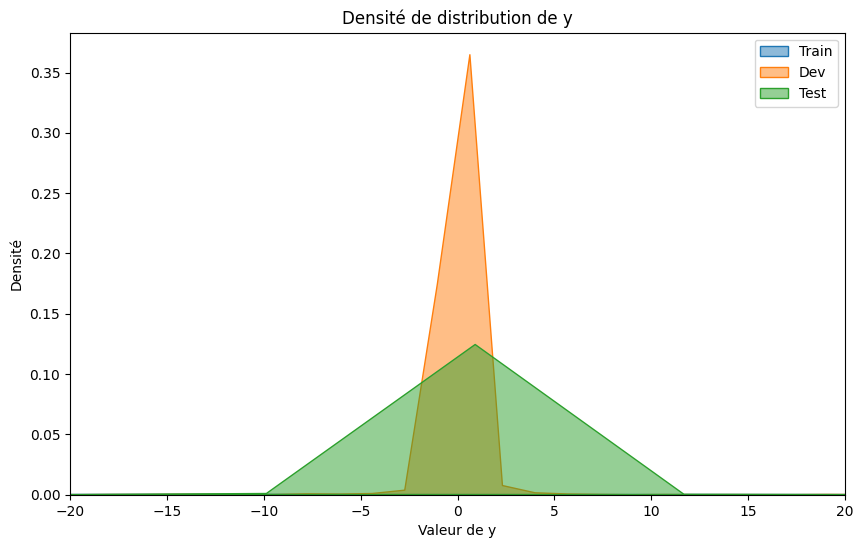

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.kdeplot(y_train.flatten(), label='Train', fill=True, alpha=0.5)
sns.kdeplot(y_dev.flatten(), label='Dev', fill=True, alpha=0.5)
sns.kdeplot(y_test.flatten(), label='Test', fill=True, alpha=0.5)

plt.title("Densité de distribution de y")
plt.xlabel("Valeur de y")
plt.ylabel("Densité")
plt.xlim(-20, 20)  # Limites x entre -10% et 10%
plt.legend()
plt.show()